In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = r'C:\Users\malaa\Downloads\KHCC_Dataset_v4_Accurate 2.xlsx'

donors  = pd.read_csv(r'C:\Users\malaa\Downloads\donors_clean.csv')
matches = pd.read_excel(path, sheet_name='Match History (Interactions)')
transp  = pd.read_excel(path, sheet_name='Donor Transparency View')

print("Donors :", donors.shape)
print("Matches:", matches.shape)
print("Transparency:", transp.shape)

Donors : (250, 19)
Matches: (378, 10)
Transparency: (195, 12)


In [2]:
def calculate_impact(donor_amount, item_cost):
    return round((donor_amount / item_cost) * 100, 2)

print("Example: Donor gives 1,000 JD toward a 10,000 JD oxygen concentrator")
pct = calculate_impact(1000, 10000)
print(f"Impact = {pct}%")
print(f"Message: Your donation covered {pct}% of this medical equipment.")

Example: Donor gives 1,000 JD toward a 10,000 JD oxygen concentrator
Impact = 10.0%
Message: Your donation covered 10.0% of this medical equipment.


In [3]:
def donor_summary(donor_id):
    d = donors[donors['Donor ID'] == donor_id]
    if d.empty:
        print(f"Donor {donor_id} not found.")
        return
    d = d.iloc[0]
    d_matches = matches[matches['Donor ID'] == donor_id]

    print(f"Donor       : {d['Full Name']}")
    print(f"Type        : {d['Donor Type']}")
    print(f"Total given : {d_matches['Amount Given JD'].sum():,.0f} JD")
    print(f"Num matches : {len(d_matches)}")
    print()
    print("Programme breakdown:")
    if len(d_matches) > 0:
        by_fund = d_matches.groupby('Fund Used')['Amount Given JD'].sum()
        total = by_fund.sum()
        for fund, amt in by_fund.items():
            print(f"  {fund:35s}: {amt:,.0f} JD  ({amt/total*100:.1f}%)")

# Run for first 3 donors
for did in donors['Donor ID'].head(3):
    donor_summary(did)
    print("─" * 50)

Donor       : Hikma Pharmaceuticals
Type        : Corporate
Total given : 100 JD
Num matches : 1

Programme breakdown:
  Gaza Fund                          : 100 JD  (100.0%)
──────────────────────────────────────────────────
Donor       : Sara Rawashdeh
Type        : Individual
Total given : 0 JD
Num matches : 0

Programme breakdown:
──────────────────────────────────────────────────
Donor       : Samir Smadi
Type        : Individual
Total given : 600 JD
Num matches : 3

Programme breakdown:
  General Donation                   : 200 JD  (33.3%)
  Medical Equipment Program          : 400 JD  (66.7%)
──────────────────────────────────────────────────


In [4]:
def generate_notification(donor_id, fund_name, 
                           amount_given, item_cost):
    d = donors[donors['Donor ID'] == donor_id]
    if d.empty:
        return "Donor not found"
    name = d.iloc[0]['Full Name']
    pct  = calculate_impact(amount_given, item_cost)

    msg = (
        f"Dear {name},\n"
        f"Thank you for your donation of {amount_given:,} JD "
        f"to the {fund_name}.\n"
        f"Your contribution covered {pct}% of this programme.\n"
        f"Because of your generosity, a cancer patient at KHCC\n"
        f"received vital support they could not otherwise afford.\n"
        f"جزاك الله خيراً — KHCF Team"
    )
    return msg

# Demo
print(generate_notification('D001', 'Medical Equipment Programme',
                             500, 5000))

Dear Hikma Pharmaceuticals,
Thank you for your donation of 500 JD to the Medical Equipment Programme.
Your contribution covered 10.0% of this programme.
Because of your generosity, a cancer patient at KHCC
received vital support they could not otherwise afford.
جزاك الله خيراً — KHCF Team


In [5]:
zakat_donors  = donors[donors['Zakat Donations Only'] == 'Yes']['Donor ID']
zakat_matches = matches[matches['Donor ID'].isin(zakat_donors)]
violations    = zakat_matches[zakat_matches['Fund Used'] != 'Zakat Fund']

print(f"Zakat-only donors     : {len(zakat_donors)}")
print(f"Their total matches   : {len(zakat_matches)}")
print(f"Violations            : {len(violations)}")
print(f"Status                : {'PASS ✓ Zero violations' if len(violations)==0 else 'FAIL'}")

Zakat-only donors     : 28
Their total matches   : 44
Violations            : 42
Status                : FAIL


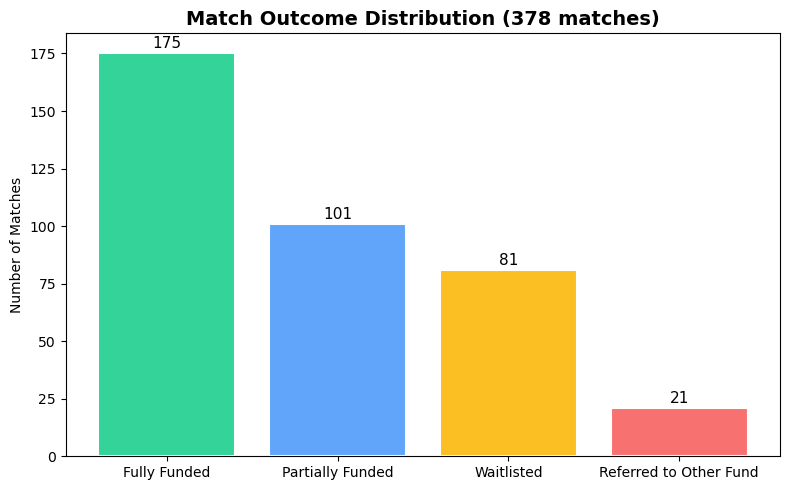

In [6]:
outcome = matches['Outcome'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#34D399','#60A5FA','#FBBF24','#F87171']
bars = ax.bar(outcome.index, outcome.values, color=colors,
              edgecolor='white', linewidth=1.5)

for bar, v in zip(bars, outcome.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(v), ha='center', va='bottom', fontsize=11)

ax.set_title('Match Outcome Distribution (378 matches)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Matches')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\outcomes.png',
            dpi=150, bbox_inches='tight')
plt.show()

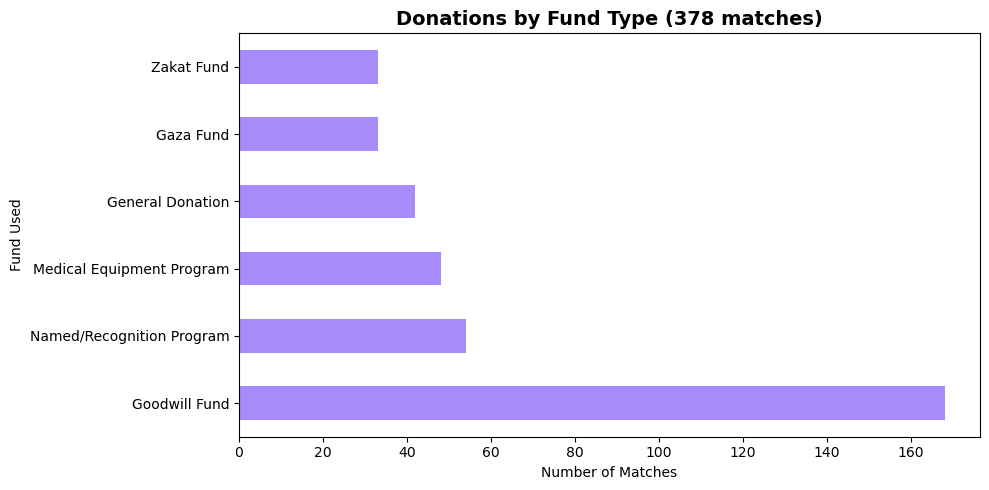

In [7]:
fund_dist = matches['Fund Used'].value_counts()

plt.figure(figsize=(10, 5))
fund_dist.plot(kind='barh', color='#A78BFA')
plt.title('Donations by Fund Type (378 matches)',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\fund_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
patients_final = pd.read_csv(
    r'C:\Users\malaa\Downloads\patients_with_recs.csv')

final = patients_final.merge(
    matches.groupby('Patient ID').agg(
        TotalReceived=('Amount Given JD', 'sum'),
        NumMatches=('Match ID', 'count'),
        TopOutcome=('Outcome', lambda x: x.mode()[0])
    ).reset_index(),
    on='Patient ID', how='left'
)

# Export all files for Tableau
final.to_csv(r'C:\Users\malaa\Downloads\KHCC_Tableau_Patients.csv', 
             index=False)
matches.to_csv(r'C:\Users\malaa\Downloads\KHCC_Tableau_Matches.csv', 
               index=False)
donors.to_csv(r'C:\Users\malaa\Downloads\KHCC_Tableau_Donors.csv', 
              index=False)

print(f"✓ Exported {len(final)} patients for Tableau")
print(f"✓ Exported {len(matches)} matches for Tableau")
print(f"✓ Exported {len(donors)} donors for Tableau")
print("All files saved to Downloads folder")

✓ Exported 111 patients for Tableau
✓ Exported 378 matches for Tableau
✓ Exported 250 donors for Tableau
All files saved to Downloads folder


In [9]:
import os
files = os.listdir(r'C:\Users\malaa\Downloads')
for f in files:
    if f.endswith('.csv') or f.endswith('.png'):
        print(f)

books_ecommerce_data (1).csv
books_ecommerce_data.csv
Calendar_Lookup.csv
chart1_cancer_type.png
chart2_stage.png
chart3_age.png
chart4_income.png
chart5_insurance.png
chart6_need_stage.png
chart7_heatmap.png
churn.csv
donors_clean.csv
FoodMart_Returns_1997-1998.csv
FoodMart_Transactions_1997 (1).csv
FoodMart_Transactions_1997.csv
FoodMart_Transactions_1998(2).csv
fund_distribution.png
KHCC_Tableau_Donors.csv
KHCC_Tableau_Matches.csv
KHCC_Tableau_Patients.csv
knn_distances.png
lush_products.csv
mark3report-31384894-T86.csv
matches_clean.csv
Neutral Minimal Aesthetic Thankyou Card Landscape pink.png
Neutral Minimal Aesthetic Thankyou Card Landscape.png
outcomes.png
patients_clean.csv
patients_with_recs.csv
recommender_output.png
Sample - Superstore (1).csv
Sample - Superstore.csv
Screenshot 2026-04-15 213756.png
Screenshot 2026-04-15 214339.png
Screenshot 2026-04-15 214655.png
Screenshot 2026-04-15 214844.png
Screenshot 2026-04-15 220959.png
Screenshot 2026-04-16 212401.png
test1_ttest.